In [1]:
import warnings
import pickle
import os

from sklearn.model_selection import train_test_split, cross_val_predict, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.utils import shuffle
from catboost import CatBoostClassifier

from cstarters.ml_utils import avg, load_dataset, featurize_alignment, confusion_matrix_plot, add_stratify_column, plot_feature_importances, importances_series_to_dict, stdev_accuracy

warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    message=".*probability.*deprecated.*"
)

random_seed = 0

In [16]:
data_dir = "../../data"
out_dir = "../../out"

In [15]:
df = load_dataset(path = os.path.join(data_dir, "cstarters_dataset.csv"))

aa_properties = {
    'WOLS870101': [936, 884, 924, 98], 
    'WOLS870102': [350, 884], 
    'WOLS870103': [98, 96, 818, 936, 986], 
    'GRAR740102': [936, 98, 350], 
    'RADA880108': [347],
    'NEU1': [936, 924]
}

df = featurize_alignment(df, aa_properties)
df['starter_category'] = df['starter_category'].apply(lambda x: x[-2:])
ml_df_full = df.drop(columns=["starter_beta_hydroxylation"])
stratify_columns = ['starter_category', 'ncbi_organism_genus']
ml_df_full = add_stratify_column(ml_df_full, stratify_columns)
ml_df_full = ml_df_full.drop(columns=['ncbi_organism_genus'])
ml_df_train, ml_df_test = train_test_split(ml_df_full, test_size = 0.2, stratify = ml_df_full['stratify_column'], random_state = random_seed)

y_train = ml_df_train['starter_category']
X_train = ml_df_train.drop(columns=['cs_accession', 'starter_category', 'stratify_column', ])
X_train, y_train = shuffle(X_train, y_train, random_state=random_seed)

y_test = ml_df_test['starter_category']
X_test = ml_df_test.drop(columns=['cs_accession', 'starter_category', 'stratify_column'])
X_test, y_test = shuffle(X_test, y_test, random_state=random_seed)

y_full = ml_df_full['starter_category']
X_full = ml_df_full.drop(columns=['cs_accession', 'starter_category', 'stratify_column'])
X_full, y_full = shuffle(X_full, y_full, random_state=random_seed)


# Train

[0.90625 0.96875 0.8125  0.8125  0.90625] avg: 0.88125


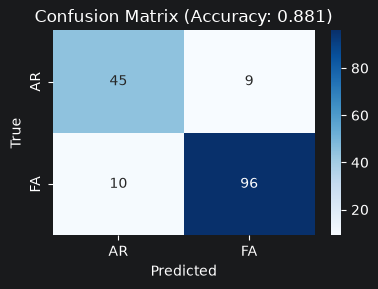

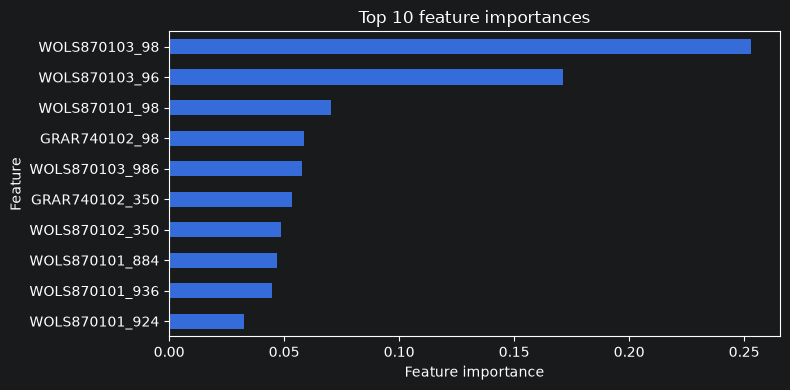

WOLS870103_98     0.252921
WOLS870103_96     0.171432
WOLS870101_98     0.070530
GRAR740102_98     0.058588
WOLS870103_986    0.057663
GRAR740102_350    0.053538
WOLS870102_350    0.048671
WOLS870101_884    0.046828
WOLS870101_936    0.044570
WOLS870101_924    0.032513
NEU1_936          0.031924
RADA880108_347    0.029986
NEU1_924          0.023927
GRAR740102_936    0.023684
WOLS870103_818    0.022628
WOLS870103_936    0.017888
WOLS870102_884    0.012710
dtype: float64


In [3]:
# RF train
rf_params = dict(
    class_weight='balanced',
    ccp_alpha=0.01,
    max_depth=9,
    min_samples_leaf=3,
    max_leaf_nodes=7,
    min_samples_split=8,
    n_estimators=100,
    max_features="log2",
    random_state=random_seed
)
model = RandomForestClassifier(**rf_params)

cv = cross_val_score(model, X_train, y_train, cv=5)
print(cv, 'avg:',  avg(cv))
cv_pred = cross_val_predict(model, X_train, y_train, cv=5)

confusion_matrix_plot(confusion_matrix(y_train, cv_pred), ["AR", "FA"])

model_importances = RandomForestClassifier(**rf_params)
model_importances.fit(X_train, y_train)
importances = plot_feature_importances(model_importances, X_train.columns, combine_at_position=False)
print(importances)

[0.96875 0.9375  0.84375 0.90625 0.9375 ] avg: 0.91875


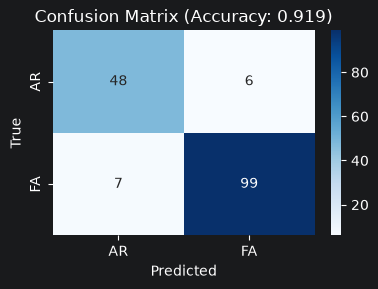

In [4]:
# SVM train
svm_params = dict(
    probability=True,
    C = 1.9, 
    class_weight='balanced'
)
model = svm.SVC(**svm_params)

cv = cross_val_score(model, X_train, y_train, cv=5)
print(cv, 'avg:',  avg(cv))
cv_pred = cross_val_predict(model, X_train, y_train, cv=5)

confusion_matrix_plot(confusion_matrix(y_train, cv_pred), ["AR", "FA"])

[0.90625 0.8125  0.71875 0.875   0.84375] avg: 0.83125


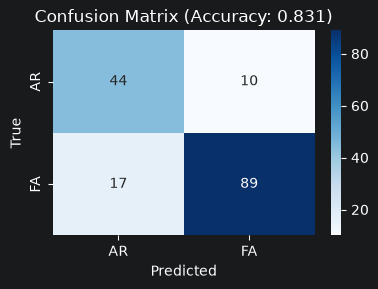

In [5]:
# LR train
lr_params = dict(
    solver='liblinear', 
    class_weight='balanced', 
    # penalty='l2', 
    C=0.3
)
model = LogisticRegression(**lr_params)

cv = cross_val_score(model, X_train, y_train, cv=5)
print(cv, 'avg:',  avg(cv))
cv_pred = cross_val_predict(model, X_train, y_train, cv=5)

confusion_matrix_plot(confusion_matrix(y_train, cv_pred), ["AR", "FA"])

[0.96875 1.      0.84375 0.875   1.     ] avg: 0.9375


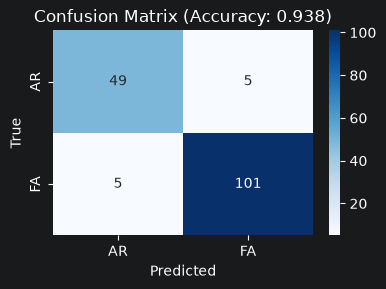

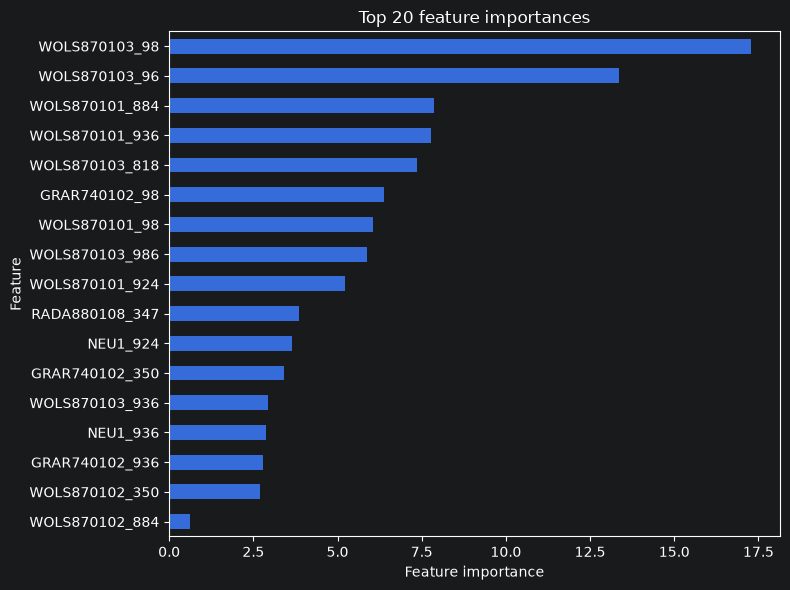

{'WOLS870103': [98, 96, 818, 986, 936], 'WOLS870101': [884, 936, 98, 924], 'GRAR740102': [98, 350, 936], 'RADA880108': [347], 'NEU1': [924, 936], 'WOLS870102': [350]}


In [6]:
# catboost train
cat_params = dict(
    iterations=250,
    learning_rate=0.03,
    depth=3,
    l2_leaf_reg=3,
    loss_function="Logloss",
    auto_class_weights="Balanced",
    random_seed=random_seed,
    verbose=0
)

model = CatBoostClassifier(**cat_params)

cv = cross_val_score(model, X_train, y_train, cv=5)
print(cv, "avg:", avg(cv))

cv_pred = cross_val_predict(model, X_train, y_train, cv=5)

confusion_matrix_plot(confusion_matrix(y_train, cv_pred),["AR", "FA"])

model_importances = CatBoostClassifier(**cat_params)
model_importances.fit(X_train, y_train)
importances = plot_feature_importances(model_importances, X_train.columns, combine_at_position=False, top_n=20)

print(importances_series_to_dict(importances, num_features=15))


# Test

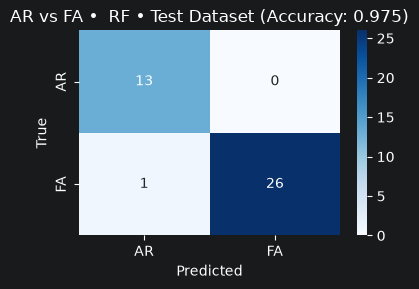

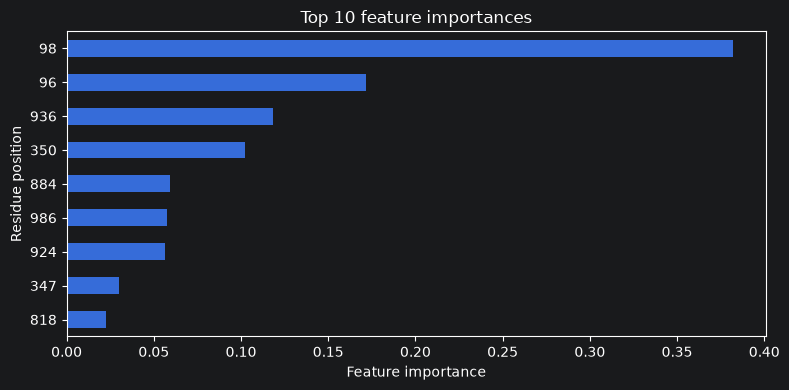

98     0.382039
96     0.171432
936    0.118066
350    0.102209
884    0.059539
986    0.057663
924    0.056439
347    0.029986
818    0.022628
dtype: float64

In [7]:
# RF test
model = RandomForestClassifier(**rf_params)

model.fit(X_train, y_train)
model_pred = model.predict(X_test)

confusion_matrix_plot(confusion_matrix(y_test, model_pred), ["AR", "FA"], title="AR vs FA •  RF • Test Dataset")

plot_feature_importances(model, X_test.columns)

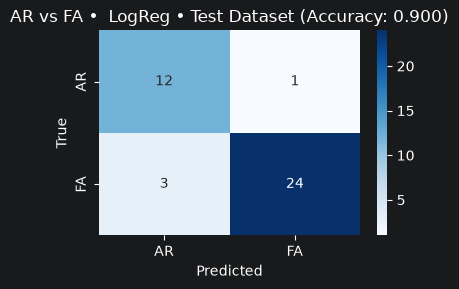

In [8]:
# LR test
model = LogisticRegression(**lr_params)

model.fit(X_train, y_train)
model_pred = model.predict(X_test)

confusion_matrix_plot(confusion_matrix(y_test, model_pred), ["AR", "FA"], title="AR vs FA •  LogReg • Test Dataset")

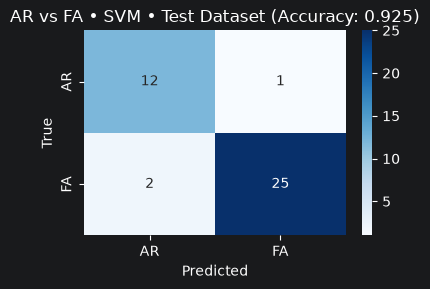

In [9]:
# SVM test
model = svm.SVC(**svm_params)

model.fit(X_train, y_train)
model_pred = model.predict(X_test)

confusion_matrix_plot(confusion_matrix(y_test, model_pred), ["AR", "FA"], title="AR vs FA • SVM • Test Dataset")

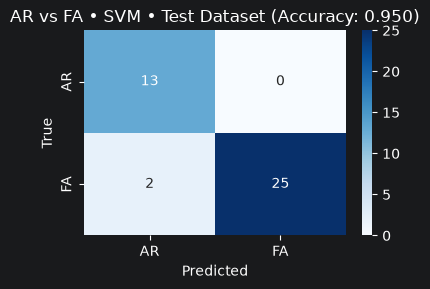

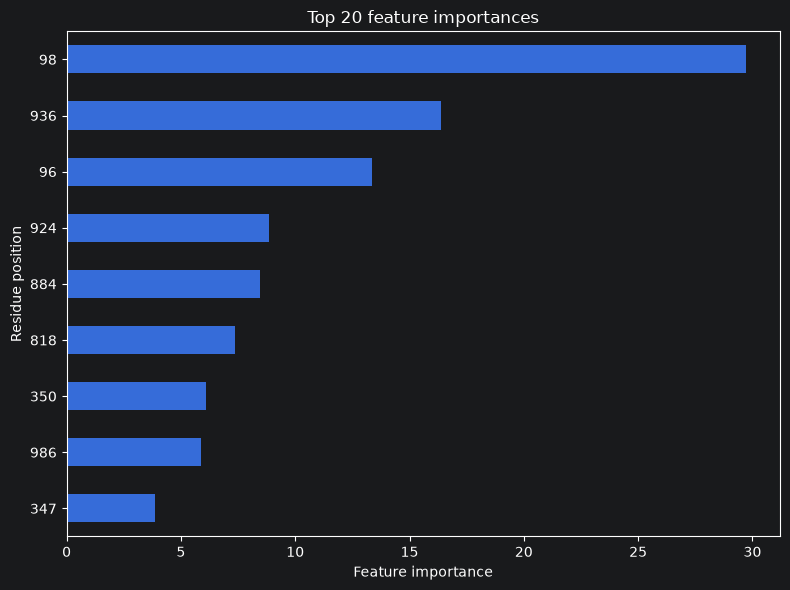

98     29.719342
936    16.375488
96     13.365408
924     8.874146
884     8.477817
818     7.370339
350     6.097210
986     5.874956
347     3.845294
dtype: float64

In [10]:
# catboost test
model = CatBoostClassifier(**cat_params)

model.fit(X_train, y_train)
model_pred = model.predict(X_test)

confusion_matrix_plot(confusion_matrix(y_test, model_pred), ["AR", "FA"], title="AR vs FA • SVM • Test Dataset")

plot_feature_importances(model, X_test.columns, top_n=20)

# Full

[0.95  0.85  0.95  0.95  0.775] avg: 0.8950000000000001


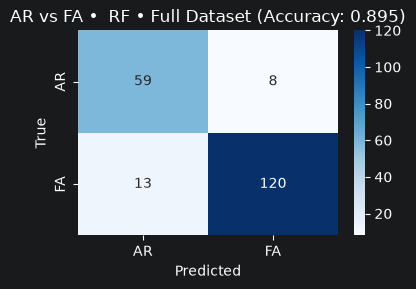

In [11]:
# RF full
model = RandomForestClassifier(**rf_params)

cv = cross_val_score(model, X_full, y_full, cv=5)
print(cv, 'avg:',  avg(cv))
cv_pred = cross_val_predict(model, X_full, y_full, cv=5)

confusion_matrix_plot(confusion_matrix(y_full, cv_pred), ["AR", "FA"], title="AR vs FA •  RF • Full Dataset")

[0.975 0.925 0.85  0.975 0.925] avg: 0.93


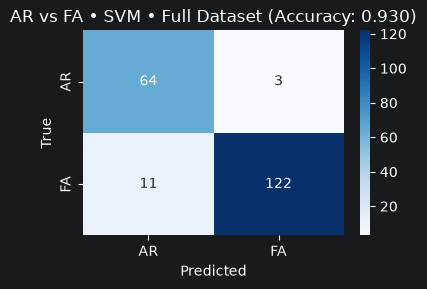

(np.float64(0.9277500000000001), np.float64(0.01015812482695502))

In [12]:
# SVM full
model = svm.SVC(**svm_params)

cv = cross_val_score(model, X_full, y_full, cv=5)
print(cv, 'avg:',  avg(cv))
cv_pred = cross_val_predict(model, X_full, y_full, cv=5)

confusion_matrix_plot(confusion_matrix(y_full, cv_pred), ["AR", "FA"], title="AR vs FA • SVM • Full Dataset")
stdev_accuracy(model, X_full, y_full, iterations=100)

[0.975 0.85  0.875 0.875 0.8  ] avg: 0.875


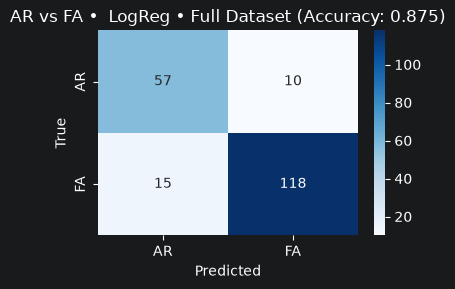

In [13]:
# LR full
model = LogisticRegression(**lr_params)

cv = cross_val_score(model, X_full, y_full, cv=5)
print(cv, 'avg:',  avg(cv))
cv_pred = cross_val_predict(model, X_full, y_full, cv=5)

confusion_matrix_plot(confusion_matrix(y_full, cv_pred), ["AR", "FA"], title="AR vs FA •  LogReg • Full Dataset")

[0.95  0.9   0.975 0.95  0.9  ] avg: 0.9350000000000002


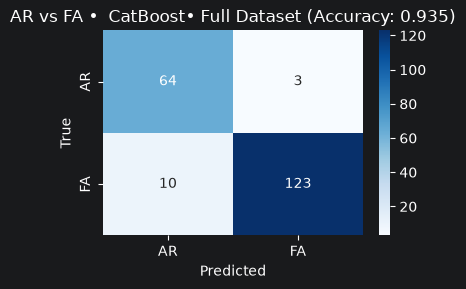

(np.float64(0.9307000000000001), np.float64(0.01102315744240279))

In [14]:
# catboost full
model = CatBoostClassifier(**cat_params)

cv = cross_val_score(model, X_full, y_full, cv=5)
print(cv, 'avg:',  avg(cv))
cv_pred = cross_val_predict(model, X_full, y_full, cv=5)

confusion_matrix_plot(confusion_matrix(y_full, cv_pred), ["AR", "FA"], title="AR vs FA •  CatBoost• Full Dataset")

stdev_accuracy(model, X_full, y_full, iterations=100)

In [17]:
model = CatBoostClassifier(**cat_params)

model.fit(X_full, y_full)

pickle.dump(model, open(os.path.join(out_dir, "ml_aromaticity.pkl"), "wb"))